# Demo 5 - Classificação de objetos

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

## 1. Requerimentos

### 1.1 Bibliotecas

Todas as bibliotecas já estão instaladas no Google Colab.

* OpenCV
* Pillow
* Pytorch
* Numpy
* Keras
* Tensorflow
* Gdown

### 1.2 Arquivos

Carregando imagens previamente existentes.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf # Explicitly import tensorflow
# Removed `import keras` to avoid ambiguity

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import Model, layers # Explicitly use tf.keras
from tensorflow.keras.models import load_model, model_from_json # Explicitly use tf.keras
from tensorflow.keras.utils import image_dataset_from_directory # For new data loading

## 2. Transfer learning para reconhecimento de imagens

Técnica de transfer learning aplicado a deep learnig para classificação de imagens, utilizando classificados com pesos já treinados disponibilizados no Keras.

Foram utilizadas imagens com tamanho 100 x 100 pixels, 1409 imagens por classe para o treinamento e 472 imagens por classe para validação.

### 2.1 Geradores de imagens

Os geradores utilizados foram aplicados para converter o tamanho adequado do modelo utilizado (224 x 224 pixels) como também para criar novos exemplos a partir das imagens no que chamamos de _data augmentation_, por meio de perturbações da imagem baseado em recorte (```shear```), zoom e orientação horizontal (```horizontal_flip```).

Conjunto de dados utilizado foi [este](https://www.kaggle.com/moltean/fruits), disponível no Kaggle.

*Adaptado deste [artigo](https://medium.freecodecamp.org/keras-vs-pytorch-avp-transfer-learning-c8b852c31f02), de Patryk Miziula*

Com a técnica de _data augmentation_ foram geradas 1212 imagens por classe. Ao todo, o número de imagens subiu de 794 para 2424.

In [23]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32 # Original batch size was 32

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    "drive/My Drive/imagens-frutas/train",
    labels='inferred',
    label_mode='int', # 'int' for sparse_categorical_crossentropy
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    "drive/My Drive/imagens-frutas/validation",
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # Typically false for validation
)

# Get class names
class_names = train_ds.class_names
print(f"Detected class names: {class_names}")

# Data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.2),
    layers.RandomRotation(0.1), # Approximating shear_range
])

# Preprocessing function to apply VGG16's preprocess_input and augmentation
def process_train_data(image, label):
    image = data_augmentation(image) # Apply augmentation
    image = preprocess_input(image)  # Then apply VGG16 specific preprocessing
    return image, label

def process_validation_data(image, label):
    image = preprocess_input(image) # Only apply VGG16 preprocessing for validation
    return image, label

# Apply preprocessing and data augmentation
train_ds = train_ds.map(process_train_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.map(process_validation_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Found 1409 files belonging to 3 classes.
Found 473 files belonging to 3 classes.
Detected class names: ['Apple Braeburn', 'Avocado', 'Banana']


Exibindo as classes identificadas.

In [24]:
print("Class names identified by the dataset generator:")
print(class_names)
# If you need a dictionary mapping names to integer indices:
# class_indices = {name: i for i, name in enumerate(class_names)}
# print("Class indices mapping:")
# print(class_indices)

Class names identified by the dataset generator:
['Apple Braeburn', 'Avocado', 'Banana']


### 2.2. Construindo a rede neural baseado em modelo pré-treinado

O Keras já possui classes especializadas para os seguintes modelos de deep-learning treinados com o conjunto de dados [ImageNet](http://www.image-net.org/):
  
* Xception
* VGG16
* VGG19
* ResNet50
* InceptionV3
* InceptionResNetV2
* MobileNet
* DenseNet
* NASNet
* MobileNetV2

Mais detalhes, veja na [documentação do Keras](https://keras.io/applications/).

_O Keras se encarrega de baixar o modelo automaticamente, não é preciso baixar separadamente._

Note que o parâmetro ```include_top=False``` configura o modelo para não utilizar a camada densa original, pois será substituída pelas novas classes.

In [25]:
conv_base = VGG16(include_top=False)

for layer in conv_base.layers:
    layer.trainable = False

Removendo a camada densa para que seja adaptada para lidar com apenas 2 classes.

### 2.3 Treinamento do modelo

In [26]:
from tensorflow.keras import Model, layers # Explicitly use tf.keras
from tensorflow.keras.models import load_model, model_from_json # Explicitly use tf.keras

# Model definition from original cell 32lXPwpVFbvW
x = conv_base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
predictions = layers.Dense(len(class_names), activation='softmax')(x)
model = Model(conv_base.input, predictions)

model.summary()

# Model compilation from original cell -NWa-COIFbvW
import tensorflow as tf

optimizer = tf.optimizers.Adam()
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# The original model.fit_generator had steps_per_epoch=1, validation_steps=1.
# This is a very small amount of data for training and validation.
# We will replicate this by taking one batch from the datasets.
# For full training, remove .take(1) from both train_ds and validation_ds.
history = model.fit(
    train_ds.take(1), # Use only one batch per epoch for training
    epochs=2,
    validation_data=validation_ds.take(1) # Use only one batch for validation
)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.6250 - loss: 2.5912

1/1 ━━━━━━━━━━━━━━━━━━━━ 39s 39s/step - accuracy: 0.6250 - loss: 2.5912 - val_accuracy: 0.5000 - val_loss: 2.1638
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 40s 40s/step - accuracy: 0.5625 - loss: 1.8407 - val_accuracy: 0.8125 - val_loss: 0.4192


Armazenamento do modelo e carregamento do modelo pré-treinado.

In [27]:
# salvando o modelo no formato HDf5
model.save('model-frutas.keras')

# arquitetura das camadas em JSSON e pesos treinados em HDF5
model.save_weights('frutas.weights.h5')
with open('architecture-frutas.json', 'w') as f:
    f.write(model.to_json())

In [28]:
# carregando o modelo no formato HDf5
model = load_model('model-frutas.keras')

# arquitetura das camadas em JSSON e pesos treinados em HDF5
with open('architecture-frutas.json') as f:
    model = model_from_json(f.read())

model.load_weights('frutas.weights.h5')

### 2.4 Predição nas imagens de teste

In [29]:
import cv2

validation_img_paths = ["drive/My Drive/imagens-frutas/validation/Apple Braeburn/7_100.jpg",
                        "drive/My Drive/imagens-frutas/validation/Avocado/49_100.jpg",
                        "drive/My Drive/imagens-frutas/validation/Banana/12_100.jpg"]

img_list = [Image.open(img_path) for img_path in validation_img_paths]

Normalizando as imagens de teste, utilizando np.stack

In [30]:
validation_batch = np.stack([preprocess_input(np.array(img.resize((224,224))))
                             for img in img_list])

In [31]:
pred_probs = model.predict(validation_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


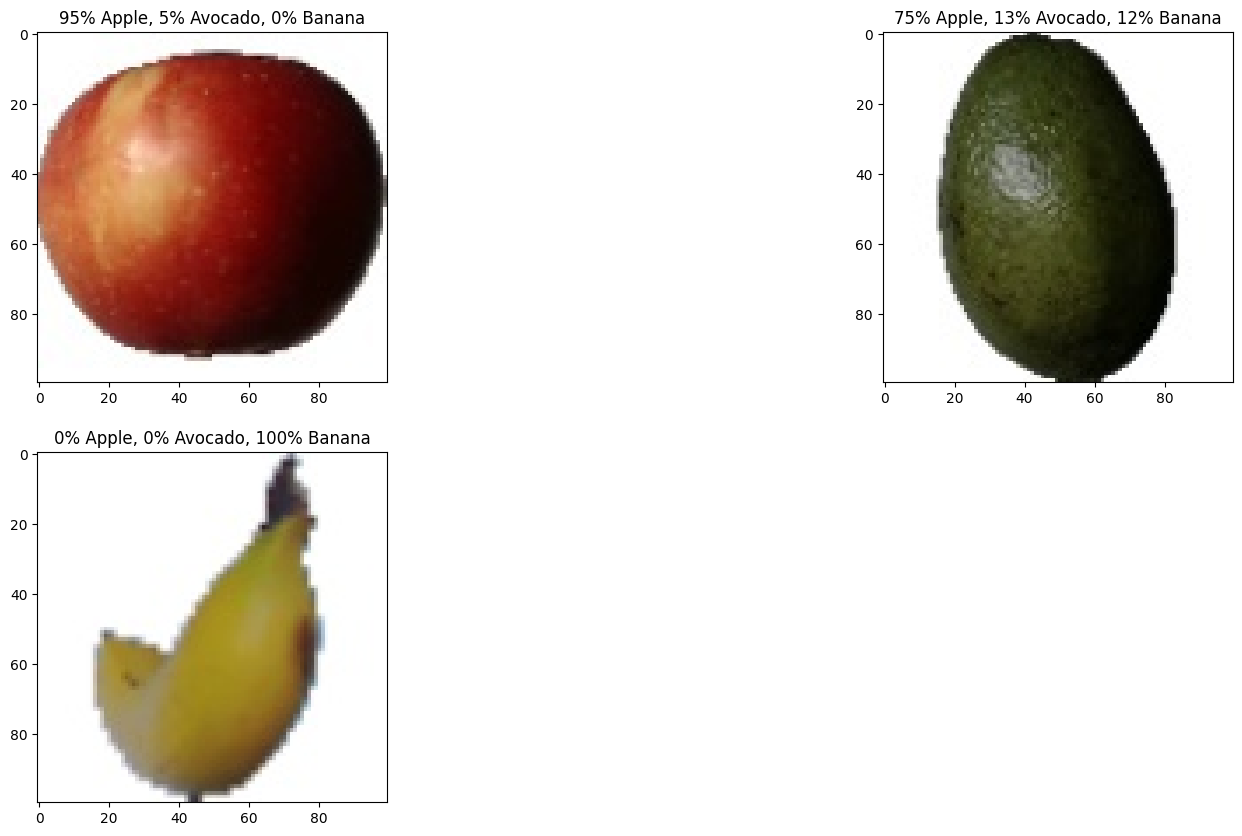

In [32]:
plt.figure(figsize=(20,10))

for i, imagem in enumerate(img_list):
    plt.subplot(2,2,i+1)
    plt.imshow(imagem)
    plt.title("{:.0f}% Apple, {:.0f}% Avocado, {:.0f}% Banana".format(100*pred_probs[i,0], 100*pred_probs[i,1], 100*pred_probs[i,2]))